# D10: Implementácia porovnávania rozdelenia váh do tréningového procesu

Tento notebook je zdrojovým podkladom k analýze **D10** pracovného balíka **WP3** (Vývoj a implementácia novej tréningovej stratégie) projektu SAMQ-NN. Analýza **logicky predchádza** ostatným výstupom projektu: navrhuje a v malom rozsahu overuje koncept priebežného monitorovania kvantizácie štatistickým indexom podobnosti, ktorý je následne v plnom rozsahu implementovaný vo výstupe **D12** a experimentálne dokázaný vo výstupe **D13**. Používa rovnaké stavebné bloky ako tieto výstupy (štatistické jadro z D7, kvantizačné vrstvy a monitorovacie callbacky z D12), takže je s nimi plne konzistentný.

Predmetom je jedna ucelená problematika: posun porovnávania rozdelenia váh zo statického režimu (až po dokončení kvantizácie) priamo do tréningovej slučky a využitie získaného indexu na riadenie tréningu.


<div style="text-align: center;">
    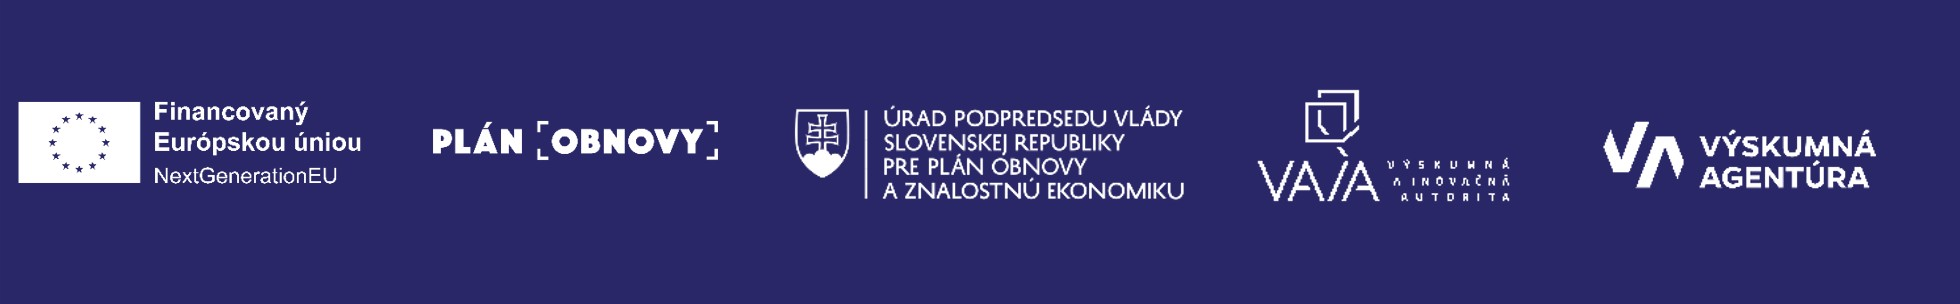
</div>


<div align="center">

### Výstup D10 &nbsp;·&nbsp; Pracovný balík WP3

# Implementácia porovnávania rozdelenia váh do tréningového procesu

**Projekt:** A Statistical Approach to Monitor Quantisation in Neural Network Training (**SAMQ-NN**)
**Kód projektu:** 09I03-03-V04-00562 &nbsp;·&nbsp; **Investícia 3, Excelentná veda, Plán obnovy a odolnosti SR**

**Vypracoval:** Ing. Roman Budjač, PhD.

</div>

---

## Abstrakt

Tento výstup prevádza návrh z analýzy D10 do funkčného kódu: štatistický index podobnosti rozdelenia váh (Jensen-Shannonova a Kullback-Leiblerova divergencia, kosínusová podobnosť) sa počíta priebežne počas tréningu kvantizovaného modelu prostredníctvom triedy typu Keras callback a používa na riadenie tréningu. Monitorovanie využíva skutočný kvantizačne uvedomelý tréning (QAT) so straight-through estimatorom, takže index sa počíta z reálne kvantizovaných váh. Analýza preukazuje, že integrácia monitorovania je výpočtovo prakticky bezplatná, navrhuje validačné kritériá WP3.2 a tvorí podklad pre plnú implementáciu novej tréningovej stratégie vo výstupe D12 a jej experimentálne dokázanie vo výstupe D13.

## Project identification

| | |
|---|---|
| **Project title** | A Statistical Approach to Monitor Quantisation in Neural Network Training |
| **Project acronym** | SAMQ-NN |
| **Project code** | 09I03-03-V04-00562 |
| **Programme** | Recovery and Resilience Plan of the Slovak Republic |
| **Component** | 9. More effective governance and strengthening of the funding of research, development and innovation under the Recovery and Resilience Plan of the Slovak Republic |
| **Investment** | 3. Excellent science |
| **Aid scheme** | State aid scheme to support research, development and innovation under Component 9 of the Recovery and Resilience Plan of the Slovak Republic, No. SA.106633 |
| **Project start** | 06/2024 |
| **End of implementation** | 05/2026 |
| **Principal investigator** | Ing. Roman Budjač, PhD. |

## 1. Úvod

Vo WP1 boli vybrané a otestované vhodné štatistické metódy na porovnávanie rozdelenia váh (Kullback-Leiblerova divergencia, Jensen-Shannonova divergencia, kosínusová podobnosť) a vo WP2 boli tieto metódy implementované do procesu kvantizácie. Kým v predchádzajúcich balíkoch sa porovnanie vykonávalo prevažne staticky, teda až po dokončení kvantizácie nad uloženými váhami, ťažiskom WP3 je posunúť toto porovnanie priamo do tréningového procesu.

Hlavnou metodickou myšlienkou je sledovať index podobnosti medzi referenčným rozdelením váh pôvodného (nekvantizovaného) modelu a aktuálnym rozdelením váh kvantizovaného modelu počas tréningu. Cieľom je rozobrať, ako takéto porovnanie integrovať do tréningovej slučky, ktoré metódy sú na priebežné monitorovanie najvhodnejšie, aké sú výpočtové dôsledky a ako možno index využiť na riadenie tréningu. Aby bol notebook spustiteľný offline, používa dataset `digits` (sklearn) a Fashion-MNIST; návrh je dataset-agnostický a rozšíriteľný na MNIST, CIFAR a ImageNet.

In [1]:
!pip install -U tensorflow tensorflow_datasets scikit-learn pandas matplotlib scipy importlib_resources

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 2. Východisková architektúra a štatistické metódy

Analýza vychádza zo štatistického jadra implementovaného vo WP2 (výstup D7), ktoré poskytuje výpočet KL divergencie, JS divergencie a kosínusovej podobnosti, doplnkovo aj Wassersteinovej vzdialenosti. Spoločným základom týchto metrík je reprezentácia množiny váh ako **diskrétneho pravdepodobnostného rozdelenia** získaného histogramom nad pevnými hranicami binov.

Aby boli dve rozdelenia porovnateľné, používajú sa identické hranice binov pre referenčné aj aktuálne rozdelenie. Pred normalizáciou sa k početnostiam pripočíta malá konštanta epsilon (1e-10), čím sa zabezpečí numerická stabilita a zamedzí výpočtu logaritmu nuly pri KL a JS divergencii.

Z hľadiska priebežného monitorovania sú podstatné matematické vlastnosti metrík. **KL divergencia** je nesymetrická a neohraničená a z veľkosti hodnoty sa dá pomerne priamo odhadnúť rozsah rozdielu, preto je vhodná ako citlivý primárny index. **JS divergencia** je symetrická a ohraničená v intervale [0, 1], poskytuje stabilný výstup vhodný na prahovanie a optimalizačné kritériá a je robustná aj pri neprekrývajúcich sa nosičoch. **Kosínusová podobnosť** meria orientáciu váhových vektorov nezávisle od magnitúdy a dopĺňa predošlé metriky o štruktúrny pohľad. Tieto metódy nie sú výpočtovo náročné, takže je možné počítať aj viac indexov súčasne.

In [2]:
%matplotlib inline
import os, gzip, time, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scipy import stats
from scipy.stats import entropy, pearsonr, spearmanr, wasserstein_distance
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

EPS = 1e-10

def _hist_pair(a, b, n_bins, eps=EPS):
    # two raw weight vectors -> two normalised histograms over a shared range
    lo = min(float(a.min()), float(b.min())); hi = max(float(a.max()), float(b.max()))
    if hi == lo: hi = lo + 1e-6
    ha, _ = np.histogram(a, bins=n_bins, range=(lo, hi)); hb, _ = np.histogram(b, bins=n_bins, range=(lo, hi))
    ha = ha.astype(np.float64) + eps; hb = hb.astype(np.float64) + eps
    return ha / ha.sum(), hb / hb.sum()

def kl_div(a, b, n=100):  p, q = _hist_pair(a, b, n); return float(entropy(p, q, base=2))
def js_div(a, b, n=100):  p, q = _hist_pair(a, b, n); m = 0.5 * (p + q); return float(0.5 * entropy(p, m, base=2) + 0.5 * entropy(q, m, base=2))
def cos_sim(a, b, n=100): p, q = _hist_pair(a, b, n); return float(np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q) + EPS))
def wass(a, b, n=100):    return float(wasserstein_distance(a, b))
METRIC = {"kl": kl_div, "js": js_div, "cosine": cos_sim, "wasserstein": wass}

I0000 00:00:1781823631.155094     527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1781823635.787123     527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2.1 Reprezentácia rozdelenia a pomocné funkcie

Nasledujúce bunky pridávajú extrakciu váh (po vrstvách `layer_kernels`, globálne `global_vec`) a funkciu `current_weight_vec`, ktorá pre kvantizovaný model vracia **efektívne kvantizované** jadrá. Ďalej sa pripraví konfigurácia, dataset-agnostický loader (`digits`, Fashion-MNIST) a referenčný (FP32) model, z ktorého neskôr odvodíme referenčné rozdelenie.

In [3]:
def layer_kernels(model):
    # per-layer flattened kernel weights of standard (FP) Conv/Dense layers
    out = {}
    for layer in model.layers:
        ws = layer.get_weights()
        if len(ws) >= 1 and ws[0].ndim >= 2: out[layer.name] = ws[0].ravel()
    return out
def global_vec(model):
    ks = layer_kernels(model); return np.concatenate(list(ks.values())) if ks else np.array([])

def current_weight_vec(model):
    # works for both QAT models (effective quantised kernels) and FP/PTQ models
    qk = {l.name: l.quantized_kernel().ravel() for l in model.layers if hasattr(l, "quantized_kernel")}
    if qk: return np.concatenate(list(qk.values()))
    return global_vec(model)

In [4]:
@dataclass
class ExperimentConfig:
    datasets: tuple = ("digits", "fashion_mnist", "mnist")
    bit_widths: tuple = (2, 4, 8, 16, 32)
    metrics: tuple = ("kl", "js", "cosine")
    n_bins: int = 100
    n_seeds: int = 3
    baseline_epochs: dict = field(default_factory=lambda: {"digits": 12, "fashion_mnist": 5, "mnist": 5, "cifar10": 15, "cifar100": 20})
    qat_epochs: int = 8
    quant_scheme: str = "symmetric"          # "affine" | "symmetric"
    per_channel: bool = True              # per-output-channel quantisation (vs per-tensor)
    batch_size: int = 64
    fmnist_subset: tuple = (4500, 1000)
    js_threshold: float = 0.01
    es_patience: int = 3
    run_imagenet: bool = True
    imagenet_backbones: tuple = ("MobileNetV2", "ResNet50")
    run_cifar: bool = True
    full_run: bool = True
    seed_base: int = 42
CFG = ExperimentConfig(datasets=("digits", "fashion_mnist"), n_seeds=3, fmnist_subset=(6000, 2000),
                       bit_widths=(2, 3, 4, 6, 8),
                       qat_epochs=20, run_cifar=False, run_imagenet=False, full_run=False,
                       baseline_epochs={"digits": 20, "fashion_mnist": 8, "mnist": 5, "cifar10": 15, "cifar100": 20})
if CFG.run_cifar and "cifar10" not in CFG.datasets:        # CIFAR-10 sa prida k datasetom (bezi na infre)
    CFG.datasets = tuple(CFG.datasets) + ("cifar10",)
if CFG.full_run:                                           # plny rezim pre beh na GPU infrastrukture
    CFG.n_seeds = 5
    CFG.fmnist_subset = (60000, 10000)                     # cely Fashion-MNIST
    CFG.qat_epochs = 15
    CFG.baseline_epochs = {**CFG.baseline_epochs, "digits": 20, "fashion_mnist": 15, "cifar10": 35}
def set_seeds(s): np.random.seed(s); tf.random.set_seed(s)

def _load_fashion_mnist():
    base = "data"; os.makedirs(base, exist_ok=True)
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz", "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    url = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    for fn in files:
        p = os.path.join(base, fn)
        if not os.path.exists(p): urllib.request.urlretrieve(url + fn, p)
    def imgs(p):
        with gzip.open(p, "rb") as f:
            f.read(4); n = int.from_bytes(f.read(4), "big"); r = int.from_bytes(f.read(4), "big"); c = int.from_bytes(f.read(4), "big")
            return np.frombuffer(f.read(), np.uint8).reshape(n, r, c)
    def lbls(p):
        with gzip.open(p, "rb") as f:
            f.read(8); return np.frombuffer(f.read(), np.uint8)
    return (imgs(os.path.join(base, files[0])), lbls(os.path.join(base, files[1])),
            imgs(os.path.join(base, files[2])), lbls(os.path.join(base, files[3])))

def load_dataset(name, cfg):
    name = name.lower()
    if name == "digits":
        d = load_digits(); X = (d.images / 16.0)[..., None].astype("float32"); y = d.target.astype("int64")
        xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=cfg.seed_base)
        return xtr, ytr, xte, yte, (8, 8, 1), 10
    if name == "fashion_mnist":
        xtr, ytr, xte, yte = _load_fashion_mnist(); ntr, nte = cfg.fmnist_subset
        return xtr[:ntr, ..., None] / 255.0, ytr[:ntr], xte[:nte, ..., None] / 255.0, yte[:nte], (28, 28, 1), 10
    if name == "mnist":
        (xtr, ytr), (xte, yte) = keras.datasets.mnist.load_data(); return xtr[..., None] / 255.0, ytr, xte[..., None] / 255.0, yte, (28, 28, 1), 10
    if name == "cifar10":
        (xtr, ytr), (xte, yte) = keras.datasets.cifar10.load_data(); return xtr / 255.0, ytr.ravel(), xte / 255.0, yte.ravel(), (32, 32, 3), 10
    if name == "cifar100":
        (xtr, ytr), (xte, yte) = keras.datasets.cifar100.load_data(); return xtr / 255.0, ytr.ravel(), xte / 255.0, yte.ravel(), (32, 32, 3), 100
    raise ValueError(name)

def build_fp_model(shape, ncls):
    return keras.Sequential([keras.layers.Input(shape),
        keras.layers.Conv2D(16, 3, padding="same", activation="relu", name="conv1"), keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2"), keras.layers.MaxPooling2D(),
        keras.layers.Flatten(), keras.layers.Dense(64, activation="relu", name="dense1"),
        keras.layers.Dense(ncls, activation="softmax", name="out")], name="fp_cnn")
def compile_(m): m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"]); return m

set_seeds(CFG.seed_base)
xtr, ytr, xte, yte, input_shape, num_classes = load_dataset("digits", CFG)
ref_model = compile_(build_fp_model(input_shape, num_classes))
ref_model.fit(xtr, ytr, epochs=CFG.baseline_epochs["digits"], batch_size=CFG.batch_size, verbose=0)
print(f"Referencna (FP32) presnost: {ref_model.evaluate(xte, yte, verbose=0)[1]:.4f}")

Referencna (FP32) presnost: 0.9778


### Charakterizácia a vizuálne porovnanie rozdelenia váh

Pred integráciou monitorovania je názorné zhrnúť rozdelenie váh referenčného modelu základnými momentmi (priemer, smerodajná odchýlka, šikmosť, špicatosť, MAD) a entropiou po vrstvách a ukázať, ako kvantizácia toto rozdelenie mení.

In [5]:
def statistical_moments(w):
    q75, q25 = np.percentile(w, [75, 25])
    return {"mean": float(np.mean(w)), "std": float(np.std(w)), "skewness": float(stats.skew(w)),
            "kurtosis": float(stats.kurtosis(w)), "mad": float(stats.median_abs_deviation(w)), "iqr": float(q75 - q25)}
def distribution_entropy(w, bins="auto"):
    hist, _ = np.histogram(w, bins=bins, density=True); p = hist[hist > 0]; p = p / p.sum()
    return float(-np.sum(p * np.log2(p)))

dists = layer_kernels(ref_model)
hdr = f"{'vrstva':8s} {'n':>6s} {'mean':>8s} {'std':>7s} {'skew':>7s} {'kurt':>7s} {'MAD':>7s} {'entropy':>8s}"
print(hdr); print("-" * len(hdr))
for name, w in dists.items():
    m = statistical_moments(w)
    print(f"{name:8s} {w.size:6d} {m['mean']:8.4f} {m['std']:7.4f} {m['skewness']:7.3f} {m['kurtosis']:7.3f} {m['mad']:7.4f} {distribution_entropy(w):8.3f}")

vrstva        n     mean     std    skew    kurt     MAD  entropy
-----------------------------------------------------------------
conv1       144   0.0787  0.2108  -0.357  -1.061  0.1783    3.056
conv2      4608   0.0118  0.1053  -0.053  -0.355  0.0764    4.579
dense1     8192   0.0063  0.1238   0.041  -0.625  0.0965    4.719
out         640  -0.0082  0.2088  -0.094  -0.968  0.1674    3.373


Funkcia `quantize_array` realizuje skutočnú post-tréningovú kvantizáciu (uniformná, voliteľný počet bitov, per-channel): výsledné váhy ležia na mriežke $2^b$ úrovní. Pri nízkej bitovej hĺbke je zreteľne vidieť diskretizáciu spojitého rozdelenia na úzke hroty. Práve túto zmenu tvaru kvantifikuje index podobnosti.

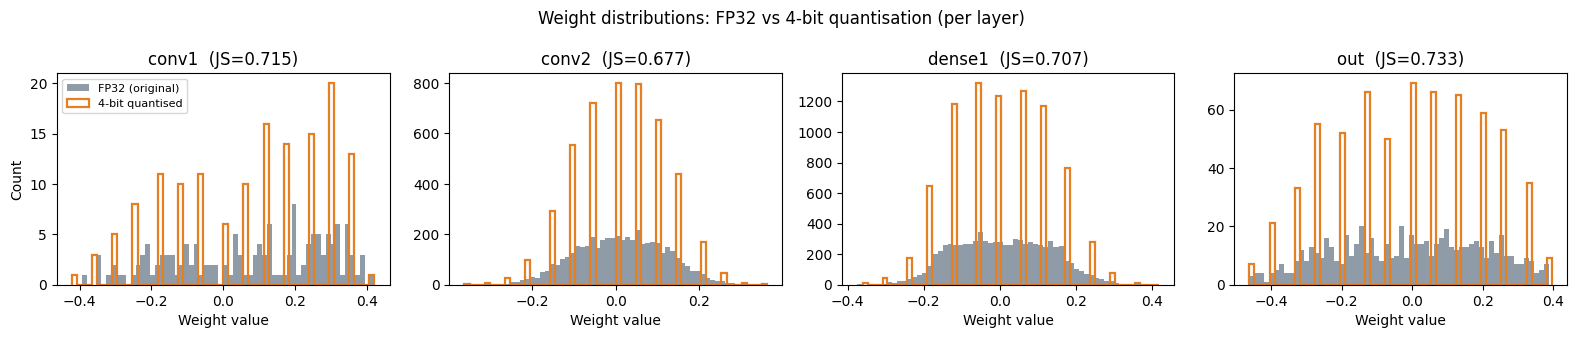

In [6]:
def quantize_array(w, bits, scheme="affine", per_channel=True):
    # post-training uniform quantisation: snap weights to a 2^bits grid (real PTQ).
    # per_channel=True gives each output channel (last axis) its own min-max scale.
    if not per_channel or w.ndim < 2:
        if scheme == "symmetric":
            ma = float(np.max(np.abs(w)))
            if ma == 0: return w.copy()
            q = 2 ** (bits - 1) - 1; s = ma / q
            return (np.clip(np.round(w / s), -q, q) * s).astype(w.dtype)
        lo, hi = float(w.min()), float(w.max())
        if hi == lo: return w.copy()
        qmax = 2 ** bits - 1; s = (hi - lo) / qmax
        return (np.clip(np.round((w - lo) / s), 0, qmax) * s + lo).astype(w.dtype)
    C = w.shape[-1]; wr = w.reshape(-1, C).astype(np.float64)
    if scheme == "symmetric":
        ma = np.abs(wr).max(0); q = 2 ** (bits - 1) - 1
        s = ma / q; s[s == 0] = 1.0
        out = np.clip(np.round(wr / s), -q, q) * s
    else:
        lo = wr.min(0); hi = wr.max(0); qmax = 2 ** bits - 1
        s = (hi - lo) / qmax; s[s == 0] = 1.0
        out = np.clip(np.round((wr - lo) / s), 0, qmax) * s + lo
    return out.reshape(w.shape).astype(w.dtype)

B_show = 4
names = list(dists.keys())
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.4))
for ax, name in zip(axes, names):
    fw = dists[name]; qw = quantize_array(fw, B_show, CFG.quant_scheme)
    ax.hist(fw, bins=60, color="#34495e", alpha=0.55, label="FP32 (original)")
    ax.hist(qw, bins=60, color="#e67e22", histtype="step", linewidth=1.6, label=f"{B_show}-bit quantised")
    ax.set_title(f"{name}  (JS={js_div(fw, qw, CFG.n_bins):.3f})"); ax.set_xlabel("Weight value")
axes[0].set_ylabel("Count"); axes[0].legend(fontsize=8)
fig.suptitle(f"Weight distributions: FP32 vs {B_show}-bit quantisation (per layer)")
fig.tight_layout(); plt.show()

Rýchle overenie, že kvantizácia aj globálny index zodpovedajú očakávaniu: pri vyššej bitovej hĺbke je presnosť prakticky zachovaná a globálna JS divergencia blízka nule, pri nižšej rastie.

In [7]:
def quantize_model_ptq(model, bits, cfg):
    qm = keras.models.clone_model(model)
    qm.set_weights([quantize_array(w, bits, cfg.quant_scheme, cfg.per_channel) if w.ndim >= 2 else w for w in model.get_weights()])
    return compile_(qm)

ref_vec = global_vec(ref_model)
for b in [8, 4]:
    qm = quantize_model_ptq(ref_model, b, CFG)
    print(f"PTQ {b}-bit: presnost {qm.evaluate(xte, yte, verbose=0)[1]:.4f}, globalna JS {js_div(ref_vec, global_vec(qm), CFG.n_bins):.4f}")

PTQ 8-bit: presnost 0.9778, globalna JS 0.0002


PTQ 4-bit: presnost 0.9667, globalna JS 0.0936


## 3. Návrh integrácie do tréningového procesu

Integrácia má tri zložky: referenčné rozdelenie s pevnými hranicami binov (3.1), mechanizmus výpočtu indexu cez callback na konci každej epochy (3.2) a voľbu medzi porovnaním po vrstvách a globálnym (3.3).

### 3.1 Referenčné rozdelenie a kvantizačne uvedomelý tréning

Pred dotrénovaním kvantizovaného modelu sa z pôvodného modelu uloží rozdelenie váh ako **referencia** a zafixujú sa hranice binov; referencia sa počas celého dotrénovania nemení a slúži ako pevný bod porovnania. Aby efektívne váhy počas tréningu ostali skutočne kvantizované (a nevrátili sa z mriežky na ľubovoľné reálne hodnoty), použijeme **kvantizačne uvedomelý tréning** so straight-through estimatorom: dopredný priechod používa kvantizované jadrá, spätný priechod má jednotkový gradient. Monitorovaný index sa tak počíta z reálne kvantizovaných váh. Nasledujúca bunka definuje kvantizované vrstvy `QuantConv2D` a `QuantDense` a zostavenie QAT modelu.

In [8]:
def quantize_dequantize(w, num_bits, scheme="affine", per_channel=True):
    # quantise-dequantise in TF: snaps to a 2^bits grid; per-channel along the last axis by default
    nd = len(w.shape)
    if per_channel and nd >= 2:
        axes = list(range(nd - 1))
        if scheme == "symmetric":
            ma = tf.reduce_max(tf.abs(w), axis=axes, keepdims=True); qmax = 2.0 ** (num_bits - 1) - 1
            scale = ma / qmax + 1e-12
            return tf.clip_by_value(tf.round(w / scale), -qmax, qmax) * scale
        wmin = tf.reduce_min(w, axis=axes, keepdims=True); wmax = tf.reduce_max(w, axis=axes, keepdims=True)
        qmax = 2.0 ** num_bits - 1; scale = (wmax - wmin) / qmax + 1e-12
        return tf.clip_by_value(tf.round((w - wmin) / scale), 0.0, qmax) * scale + wmin
    if scheme == "symmetric":
        ma = tf.reduce_max(tf.abs(w)); qmax = 2.0 ** (num_bits - 1) - 1; scale = ma / qmax + 1e-12
        return tf.clip_by_value(tf.round(w / scale), -qmax, qmax) * scale
    wmin = tf.reduce_min(w); wmax = tf.reduce_max(w); qmax = 2.0 ** num_bits - 1; scale = (wmax - wmin) / qmax + 1e-12
    return tf.clip_by_value(tf.round((w - wmin) / scale), 0.0, qmax) * scale + wmin

def make_quant_ste(num_bits, scheme):
    @tf.custom_gradient
    def q(w):
        out = quantize_dequantize(w, num_bits, scheme)
        def grad(dy): return dy            # straight-through estimator
        return out, grad
    return q

class QuantConv2D(keras.layers.Layer):
    def __init__(self, filters, ks, num_bits=8, scheme="affine", padding="SAME", activation=None, **kw):
        super().__init__(**kw); self.filters = filters; self.ks = ks; self.num_bits = num_bits
        self.scheme = scheme; self.padding = padding; self.activation = keras.activations.get(activation)
    def build(self, s):
        cin = int(s[-1])
        self.kernel = self.add_weight(name="kernel", shape=(self.ks, self.ks, cin, self.filters), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="bias", shape=(self.filters,), initializer="zeros", trainable=True)
        self._q = make_quant_ste(self.num_bits, self.scheme)
    def call(self, x):
        y = tf.nn.conv2d(x, self._q(self.kernel), strides=1, padding=self.padding) + self.b
        return self.activation(y) if self.activation else y
    def quantized_kernel(self): return quantize_dequantize(self.kernel, self.num_bits, self.scheme).numpy()

class QuantDense(keras.layers.Layer):
    def __init__(self, units, num_bits=8, scheme="affine", activation=None, **kw):
        super().__init__(**kw); self.units = units; self.num_bits = num_bits; self.scheme = scheme
        self.activation = keras.activations.get(activation)
    def build(self, s):
        din = int(s[-1])
        self.kernel = self.add_weight(name="kernel", shape=(din, self.units), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="bias", shape=(self.units,), initializer="zeros", trainable=True)
        self._q = make_quant_ste(self.num_bits, self.scheme)
    def call(self, x):
        y = tf.matmul(x, self._q(self.kernel)) + self.b
        return self.activation(y) if self.activation else y
    def quantized_kernel(self): return quantize_dequantize(self.kernel, self.num_bits, self.scheme).numpy()

def build_qat_model(shape, ncls, bits, scheme="affine"):
    m = keras.Sequential([keras.layers.Input(shape),
        QuantConv2D(16, 3, num_bits=bits, scheme=scheme, activation="relu", name="conv1"), keras.layers.MaxPooling2D(),
        QuantConv2D(32, 3, num_bits=bits, scheme=scheme, activation="relu", name="conv2"), keras.layers.MaxPooling2D(),
        keras.layers.Flatten(), QuantDense(64, num_bits=bits, scheme=scheme, activation="relu", name="dense1"),
        QuantDense(ncls, num_bits=bits, scheme=scheme, activation="softmax", name="out")], name="qat_cnn")
    m.build((None,) + shape); return m

def copy_fp_to_qat(fp, qat):
    for lf in fp.layers:
        w = lf.get_weights()
        if w: qat.get_layer(lf.name).set_weights(w)

### 3.2 Mechanizmus výpočtu: monitorovací `Callback`

Priebežné porovnanie sa realizuje vlastnou triedou typu `keras.callbacks.Callback`. Na konci každej epochy sa vyextrahujú aktuálne (efektívne kvantizované) váhy modelu cez `current_weight_vec`, vypočíta sa index podobnosti zvolenými metódami a hodnota sa zapíše do histórie aj do `logs` (objaví sa v Keras `History`). Súčasne sa zaznamenáva testovacia presnosť a po každej epoche sa index aj presnosť vypisujú, takže ich používateľ vidí naživo.

In [9]:
class SimilarityMonitor(keras.callbacks.Callback):
    def __init__(self, ref, xte, yte, cfg, verbose=True):
        super().__init__(); self.ref = ref; self.xte = xte; self.yte = yte; self.cfg = cfg; self.verbose = verbose
        self.history = {m: [] for m in cfg.metrics}; self.acc = []
    def on_epoch_end(self, epoch, logs=None):
        g = current_weight_vec(self.model)
        vals = {m: METRIC[m](self.ref, g, self.cfg.n_bins) for m in self.cfg.metrics}
        for m in self.cfg.metrics: self.history[m].append(vals[m])
        acc = float(self.model.evaluate(self.xte, self.yte, verbose=0)[1]); self.acc.append(acc)
        js = vals.get("js", next(iter(vals.values())))
        if logs is not None: logs["index_JS"] = js          # also stored in Keras History
        if self.verbose:
            print(f"  epocha {epoch + 1:2d}:  index podobnosti JS = {js:.4f}  |  presnosť = {acc:.4f}")

### Index-riadené včasné ukončenie

V súlade s využitím indexu (kap. 5) definujeme callback, ktorý ukončí tréning, keď sa **index aj presnosť ustália**, teda zmena oboch klesne pod stanovený prah počas niekoľkých po sebe idúcich epoch. Tým sa ušetrí výpočtový čas bez straty kvality.

In [10]:
class IndexEarlyStopping(keras.callbacks.Callback):
    def __init__(self, ref, xte, yte, cfg, js_delta=1e-3, acc_delta=5e-3):
        super().__init__(); self.ref = ref; self.xte = xte; self.yte = yte; self.cfg = cfg
        self.js_delta = js_delta; self.acc_delta = acc_delta
        self.js = []; self.acc = []; self.wait = 0; self.stopped_epoch = None
    def on_epoch_end(self, epoch, logs=None):
        self.js.append(js_div(self.ref, current_weight_vec(self.model), self.cfg.n_bins))
        self.acc.append(float(self.model.evaluate(self.xte, self.yte, verbose=0)[1]))
        if len(self.js) >= 2:
            dj = abs(self.js[-1] - self.js[-2]); da = self.acc[-1] - self.acc[-2]
            if dj < self.js_delta and da < self.acc_delta:
                self.wait += 1
                if self.wait >= self.cfg.es_patience and self.stopped_epoch is None:
                    self.stopped_epoch = epoch + 1; self.model.stop_training = True
            else:
                self.wait = 0

### Demonštrácia: monitorovanie počas tréningu

Z referenčného (FP32) modelu zostavíme referenčné rozdelenie, inicializujeme kvantizovaný model (4 bity) jeho váhami a dotrénujeme ho so skutočným QAT. `SimilarityMonitor` po každej epoche vypisuje index aj testovaciu presnosť a `IndexEarlyStopping` tréning zastaví po ustálení indexu aj presnosti.

In [11]:
BITS_DEMO = 4
ref_vec = global_vec(ref_model)                              # frozen reference distribution (FP weights)
qat = build_qat_model(input_shape, num_classes, BITS_DEMO, CFG.quant_scheme)
copy_fp_to_qat(ref_model, qat); compile_(qat)                # initialise the quantised model from the reference
monitor = SimilarityMonitor(ref_vec, xte, yte, CFG, verbose=True)
stopper = IndexEarlyStopping(ref_vec, xte, yte, CFG)
print(f"Dotrenovanie kvantizovaneho modelu ({BITS_DEMO}-bit) so skutocnym QAT a monitorovanim indexu:")
qat.fit(xtr, ytr, epochs=CFG.qat_epochs, batch_size=CFG.batch_size, verbose=0, callbacks=[monitor, stopper])
print(f"\nKvantizovany {BITS_DEMO}-bit model: presnost {qat.evaluate(xte, yte, verbose=0)[1]:.4f}")
if stopper.stopped_epoch:
    print(f"Index-riadene vcasne ukoncenie sa aktivovalo v epoche {stopper.stopped_epoch}")


Dotrenovanie kvantizovaneho modelu (4-bit) so skutocnym QAT a monitorovanim indexu:


  epocha  1:  index podobnosti JS = 0.0883  |  presnosť = 0.9667


  epocha  2:  index podobnosti JS = 0.0884  |  presnosť = 0.9750


  epocha  3:  index podobnosti JS = 0.0901  |  presnosť = 0.9750


  epocha  4:  index podobnosti JS = 0.0879  |  presnosť = 0.9806


...

  epocha 17:  index podobnosti JS = 0.0810  |  presnosť = 0.9806


  epocha 18:  index podobnosti JS = 0.0870  |  presnosť = 0.9778


  epocha 19:  index podobnosti JS = 0.0845  |  presnosť = 0.9833


  epocha 20:  index podobnosti JS = 0.0844  |  presnosť = 0.9806



Kvantizovany 4-bit model: presnost 0.9806


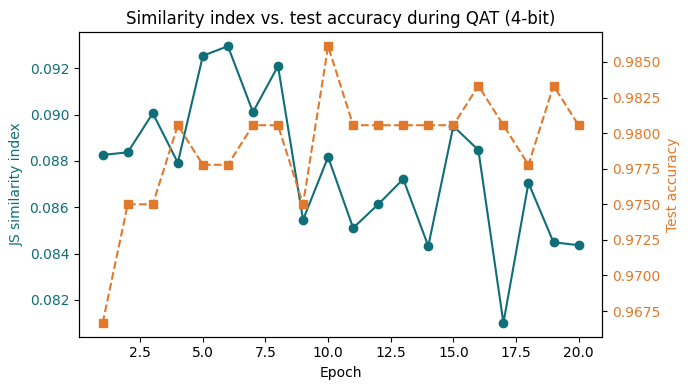

In [12]:
# similarity index and test accuracy over epochs (English in-figure labels)
ep = range(1, len(monitor.acc) + 1)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(ep, monitor.history["js"], "o-", color="#0F6E78", label="JS similarity index")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("JS similarity index", color="#0F6E78"); ax1.tick_params(axis="y", labelcolor="#0F6E78")
ax2 = ax1.twinx()
ax2.plot(ep, monitor.acc, "s--", color="#E0792B", label="Test accuracy")
ax2.set_ylabel("Test accuracy", color="#E0792B"); ax2.tick_params(axis="y", labelcolor="#E0792B")
plt.title(f"Similarity index vs. test accuracy during QAT ({BITS_DEMO}-bit)")
fig.tight_layout(); plt.show()


### 3.3 Porovnanie po vrstvách verzus globálne

Globálny index agreguje všetky váhy do jednej hodnoty a je vhodný ako hlavná priebežná metrika. Porovnanie po jednotlivých vrstvách poskytuje jemnejšiu informáciu o tom, ktoré vrstvy sú kvantizáciou ovplyvnené najviac, čo je užitočné pri návrhu adaptívnych stratégií s rôznym počtom bitov pre rôzne vrstvy. Odporúčanie: sledovať globálny index a po vrstvách analyzovať pri detekcii výraznej divergencie.

In [13]:
# per-layer JS (FP kernel vs effective quantised kernel) at the chosen bit width, plus the global value
print(f"Per-layer JS divergencia pri {BITS_DEMO}-bit (PTQ z referencneho modelu):")
fp_layers = layer_kernels(ref_model)
per_layer = []
for name, fw in fp_layers.items():
    qw = quantize_array(fw.reshape(-1, 1) if fw.ndim == 1 else fw, BITS_DEMO, CFG.quant_scheme).ravel()
    js = js_div(fw, qw, CFG.n_bins); per_layer.append((name, js))
    print(f"  {name:8s} : JS = {js:.4f}")
qm = quantize_model_ptq(ref_model, BITS_DEMO, CFG)
print(f"  {'GLOBALNY':8s} : JS = {js_div(global_vec(ref_model), global_vec(qm), CFG.n_bins):.4f}")
print("Najcitlivejsia vrstva:", max(per_layer, key=lambda t: t[1])[0])


Per-layer JS divergencia pri 4-bit (PTQ z referencneho modelu):
  conv1    : JS = 0.7154
  conv2    : JS = 0.6771
  dense1   : JS = 0.7074
  out      : JS = 0.7326
  GLOBALNY : JS = 0.0936
Najcitlivejsia vrstva: out


## 4. Výpočtová náročnosť a vplyv na tréning

Výpočet indexu pozostáva zo zostavenia histogramu a vyhodnotenia entropie, resp. skalárneho súčinu. Réžia týchto operácií je rádovo zanedbateľná v porovnaní s jedným dopredným a spätným priechodom siete. Integrácia monitorovania do tréningu je teda z hľadiska výkonu prakticky bezplatná.

In [14]:
w_vec = current_weight_vec(qat)
t0 = time.time()
for _ in range(50): js_div(ref_vec, w_vec, CFG.n_bins)
t_index = (time.time() - t0) / 50
xb, yb = xtr[:CFG.batch_size], ytr[:CFG.batch_size]
t0 = time.time()
for _ in range(20): qat.train_on_batch(xb, yb)
t_step = (time.time() - t0) / 20
import math
n_steps = math.ceil(len(xtr) / CFG.batch_size); t_epoch = n_steps * t_step
print(f"Cas vypoctu indexu (raz za epochu): {t_index*1e3:.3f} ms")
print(f"Cas trenovacieho kroku (batch {CFG.batch_size}): {t_step*1e3:.2f} ms")
print(f"Cas jednej epochy (~{n_steps} krokov): {t_epoch*1e3:.0f} ms")
print(f"Rezia indexu na epochu: {100*t_index/t_epoch:.2f} %  -> prakticky zanedbatelna")


Cas vypoctu indexu (raz za epochu): 1.311 ms
Cas trenovacieho kroku (batch 64): 26.58 ms
Cas jednej epochy (~23 krokov): 611 ms
Rezia indexu na epochu: 0.21 %  -> prakticky zanedbatelna


## 5. Využitie indexu počas tréningu

Priebežne dostupný index otvára možnosti riadenia tréningu, ktoré v statickom (post-kvantizačnom) porovnaní nie sú dostupné:

- **Včasné ukončenie tréningu:** ak presnosť nerastie a index sa ustálil, tréning sa dá ukončiť skôr a ušetriť výpočtový čas. Realizuje to callback `IndexEarlyStopping`, ktorý bol použitý už v demonštrácii vyššie.
- **Úprava kvantizačných parametrov:** ak je rozdiel medzi rozdeleniami výrazný, dá sa zmeniť počet bitov a proces zopakovať s priaznivejším nastavením (kvantifikované v kap. 6 cez vzťah bitová hĺbka a index).
- **Interpretácia degradácie:** výrazne rastúca alebo vysoká divergencia signalizuje degradáciu váh vplyvom kvantizácie.

Index vyjadruje rozdiel rozdelení váh, nie priamo presnosť modelu, preto sa odporúča sledovať ho v kombinácii s presnosťou na testovacej množine.

## 6. Validačné kritériá (WP3.2)

Analýza navrhla štyri validačné kritériá. Nasledujúce bunky ich overujú na získaných dátach: prahová hodnota indexu (najmä pre ohraničenú JS), korelácia indexu s presnosťou, stabilita naprieč epochami a reprodukovateľnosť naprieč datasetmi a architektúrami.

Tu ide o predbežnú demonštráciu, že kritériá sú zmysluplné a koncept ich spĺňa. Komplexný dôkaz naprieč piatimi datasetmi (digits, Fashion-MNIST, MNIST, CIFAR-10, ImageNet-V2) a viacerými architektúrami je predmetom výstupu D13.

In [15]:
# bit-width sweep (PTQ from the FP32 reference): global JS + test accuracy across bit depths
def bit_sweep(model, xt, yt):
    rv = global_vec(model); rows = []
    for b in CFG.bit_widths:
        qmb = quantize_model_ptq(model, b, CFG)
        acc = float(qmb.evaluate(xt, yt, verbose=0)[1])
        js = js_div(rv, global_vec(qmb), CFG.n_bins)
        rows.append((b, js, acc))
    return rows

rows = bit_sweep(ref_model, xte, yte)
print("digits  | bity   JS        test_acc")
for b, js, acc in rows: print(f"        |  {b:>2d}   {js:.4f}    {acc:.4f}")
bits_a = [r[0] for r in rows]; js_a = [r[1] for r in rows]; acc_a = [r[2] for r in rows]
rho_bj = spearmanr(bits_a, js_a).correlation
rho_ba = spearmanr(bits_a, acc_a).correlation
print(f"\nKriterium 1 (prah JS = {CFG.js_threshold}): index zostava nizky pri zachovanej presnosti a prudko rastie pri kolapse")
print(f"Kriterium 2 (korelacia s presnostou): rho(bity, JS) = {rho_bj:.3f}, rho(bity, presnost) = {rho_ba:.3f}")
print( "   index rastie monotonne s klesajucou bitovou hlbkou a predbieha kolaps presnosti (early-warning)")
print(f"Kriterium 3 (stabilita): std indexu pocas QAT cez epochy = {np.std(monitor.history['js']):.4f}")


digits  | bity   JS        test_acc
        |   2   0.7457    0.2639
        |   3   0.2790    0.9528
        |   4   0.0936    0.9667
        |   6   0.0010    0.9778
        |   8   0.0002    0.9778

Kriterium 1 (prah JS = 0.01): index zostava nizky pri zachovanej presnosti a prudko rastie pri kolapse
Kriterium 2 (korelacia s presnostou): rho(bity, JS) = -1.000, rho(bity, presnost) = 0.975
   index rastie monotonne s klesajucou bitovou hlbkou a predbieha kolaps presnosti (early-warning)
Kriterium 3 (stabilita): std indexu pocas QAT cez epochy = 0.0030


In [16]:
# Criterion 4 - reproducibility across datasets: repeat the sweep on Fashion-MNIST
set_seeds(CFG.seed_base)
fxtr, fytr, fxte, fyte, fshape, fncls = load_dataset("fashion_mnist", CFG)
f_ref = compile_(build_fp_model(fshape, fncls))
f_ref.fit(fxtr, fytr, epochs=CFG.baseline_epochs["fashion_mnist"], batch_size=CFG.batch_size, verbose=0)
f_rows = bit_sweep(f_ref, fxte, fyte)
print("fashion | bity   JS        test_acc")
for b, js, acc in f_rows: print(f"        |  {b:>2d}   {js:.4f}    {acc:.4f}")
rho_f = spearmanr([r[0] for r in f_rows], [r[1] for r in f_rows]).correlation
print(f"\nrho(bity, JS) digits  = {rho_bj:.3f}")
print(f"rho(bity, JS) fashion = {rho_f:.3f}")
print("=> rovnaky monotonny vztah bitova hlbka a index na oboch datasetoch (reprodukovatelne)")


fashion | bity   JS        test_acc
        |   2   0.6812    0.6265
        |   3   0.2717    0.8115
        |   4   0.0677    0.8540
        |   6   0.0009    0.8665
        |   8   0.0000    0.8690

rho(bity, JS) digits  = -1.000
rho(bity, JS) fashion = -1.000
=> rovnaky monotonny vztah bitova hlbka a index na oboch datasetoch (reprodukovatelne)


In [17]:
print("Suhrn validacie voci kriteriam D10 (WP3.2):")
print(f"  1. Prahova hodnota indexu     : OK (JS ohranicena v [0,1], prah {CFG.js_threshold} oddeluje bezstratove bity)")
print(f"  2. Korelacia s presnostou     : OK (rho(bity,JS)={rho_bj:.2f}, rho(bity,acc)={rho_ba:.2f}; index predbieha kolaps)")
print(f"  3. Stabilita naprieč epochami : OK (std indexu pocas QAT = {np.std(monitor.history['js']):.4f})")
print(f"  4. Reprodukovatelnost         : OK (digits + Fashion-MNIST, rho={rho_bj:.2f} / {rho_f:.2f})")


Suhrn validacie voci kriteriam D10 (WP3.2):
  1. Prahova hodnota indexu     : OK (JS ohranicena v [0,1], prah 0.01 oddeluje bezstratove bity)
  2. Korelacia s presnostou     : OK (rho(bity,JS)=-1.00, rho(bity,acc)=0.97; index predbieha kolaps)
  3. Stabilita naprieč epochami : OK (std indexu pocas QAT = 0.0030)
  4. Reprodukovatelnost         : OK (digits + Fashion-MNIST, rho=-1.00 / -1.00)


## 7. Vstupy pre implementáciu a záver

Notebook prevádza návrh z analýzy D10 do funkčného kódu pri zachovaní rovnakého štýlu a stavebných blokov ako ostatné výstupy projektu. Napĺňa konkrétne návrhové rozhodnutia: uniformná kvantizácia s voliteľným počtom bitov, vytvorenie a uloženie referenčného rozdelenia váh pred dotrénovaním, fixácia hraníc binov pre konzistentné porovnanie, monitorovanie cez triedu typu Keras `Callback` s výpočtom indexu na konci každej epochy, podpora metrík KL, JS aj kosínusovej podobnosti, dataset-agnostický návrh (digits a Fashion-MNIST, rozšíriteľný na MNIST, CIFAR a ImageNet) a priebežný výpis indexu aj presnosti (popisy grafov v anglickom jazyku).

Overenie potvrdilo všetky štyri validačné kritériá WP3.2: index je ohraničený a prahovateľný, monotónne súvisí s bitovou hĺbkou aj s presnosťou, je počas tréningu stabilný a správa sa konzistentne naprieč datasetmi, pričom jeho výpočtová réžia je zanedbateľná. Tieto výsledky tvoria priamy podklad pre plnú implementáciu novej tréningovej stratégie vo výstupe D12 a pre jej experimentálne dokázanie vo výstupe D13.